# 230. Kth Smallest Element in a BST
https://leetcode.com/problems/kth-smallest-element-in-a-bst/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Iterative inorder | $O(H + k)$ | $O(H)$ | Optimal — stop after k elements |
| Recursive inorder | $O(n)$ | $O(n)$ | Collect all then pick kth |

## Methodology

Perform an iterative inorder traversal (left, visit, right) using a stack. The inorder traversal of a BST visits nodes in ascending order. Count visited nodes and return the kth one. This stops early after finding the answer.

## Solutions

### C#

In [ ]:
public class Solution {
    public int KthSmallest(TreeNode root, int k) {
        var stack = new Stack<TreeNode>();
        TreeNode curr = root;
        while (curr != null || stack.Count > 0) {
            while (curr != null) {
                stack.Push(curr);
                curr = curr.left;
            }
            curr = stack.Pop();
            if (--k == 0) return curr.val;
            curr = curr.right;
        }
        return -1;
    }
}

### Python

In [ ]:
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        stack = []
        curr = root
        while curr or stack:
            while curr:
                stack.append(curr)
                curr = curr.left
            curr = stack.pop()
            k -= 1
            if k == 0:
                return curr.val
            curr = curr.right
        return -1

### Go

In [ ]:
func kthSmallest(root *TreeNode, k int) int {
    stack := []*TreeNode{}
    curr := root
    for curr != nil || len(stack) > 0 {
        for curr != nil {
            stack = append(stack, curr)
            curr = curr.Left
        }
        curr = stack[len(stack)-1]
        stack = stack[:len(stack)-1]
        k--
        if k == 0 {
            return curr.Val
        }
        curr = curr.Right
    }
    return -1
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn kth_smallest(root: Option<Rc<RefCell<TreeNode>>>, k: i32) -> i32 {
        let mut stack: Vec<Rc<RefCell<TreeNode>>> = Vec::new();
        let mut curr = root;
        let mut k = k;
        loop {
            while let Some(node) = curr {
                curr = node.borrow().left.clone();
                stack.push(node);
            }
            if let Some(node) = stack.pop() {
                k -= 1;
                if k == 0 {
                    return node.borrow().val;
                }
                curr = node.borrow().right.clone();
            } else {
                break;
            }
        }
        -1
    }
}

## Example Scenarios

1. **Common Case** — Small balanced BST  
   **Input:** `root = [3,1,4,null,2], k = 1`  
   Inorder traversal yields $[1,2,3,4]$. The $1$st smallest is $1$. The iterative stack pops nodes in ascending order, so the very first pop gives our answer.

2. **Slightly Complex** — Deeper left-skewed BST  
   **Input:** `root = [5,3,6,2,4,null,null,1], k = 3`  
   Inorder: $[1,2,3,4,5,6]$. We pop $1$, $2$, then $3$ — the $3$rd smallest. The stack must unwind through three levels of left children before finding the answer.

3. **Edge Case: Time Factor** — $k$ equals tree size (last element)  
   **Input:** `root = [3,1,4,null,2], k = 4`  
   We must traverse the entire tree in-order: $1 \to 2 \to 3 \to 4$. The answer $4$ is the very last node visited, so this is the worst-case $O(n)$ scan.

4. **Edge Case: Space Factor** — Completely left-skewed tree (linked list)  
   **Input:** `root = [4,3,null,2,null,1], k = 1`  
   The tree degenerates into a chain $4 \to 3 \to 2 \to 1$. The stack grows to depth $n = 4$ before the first pop, making space $O(n)$ instead of $O(\log n)$.

5. **Almost-Impossible but Plausible** — Maximum constraints  
   **Input:** `root` has $10^4$ nodes with values in $[0, 10^4]$, `k = 10000`  
   With $n = k = 10^4$, we traverse every node. Even in the worst-case skewed tree the stack holds $10^4$ frames — well within memory. The answer is the maximum value in the BST.

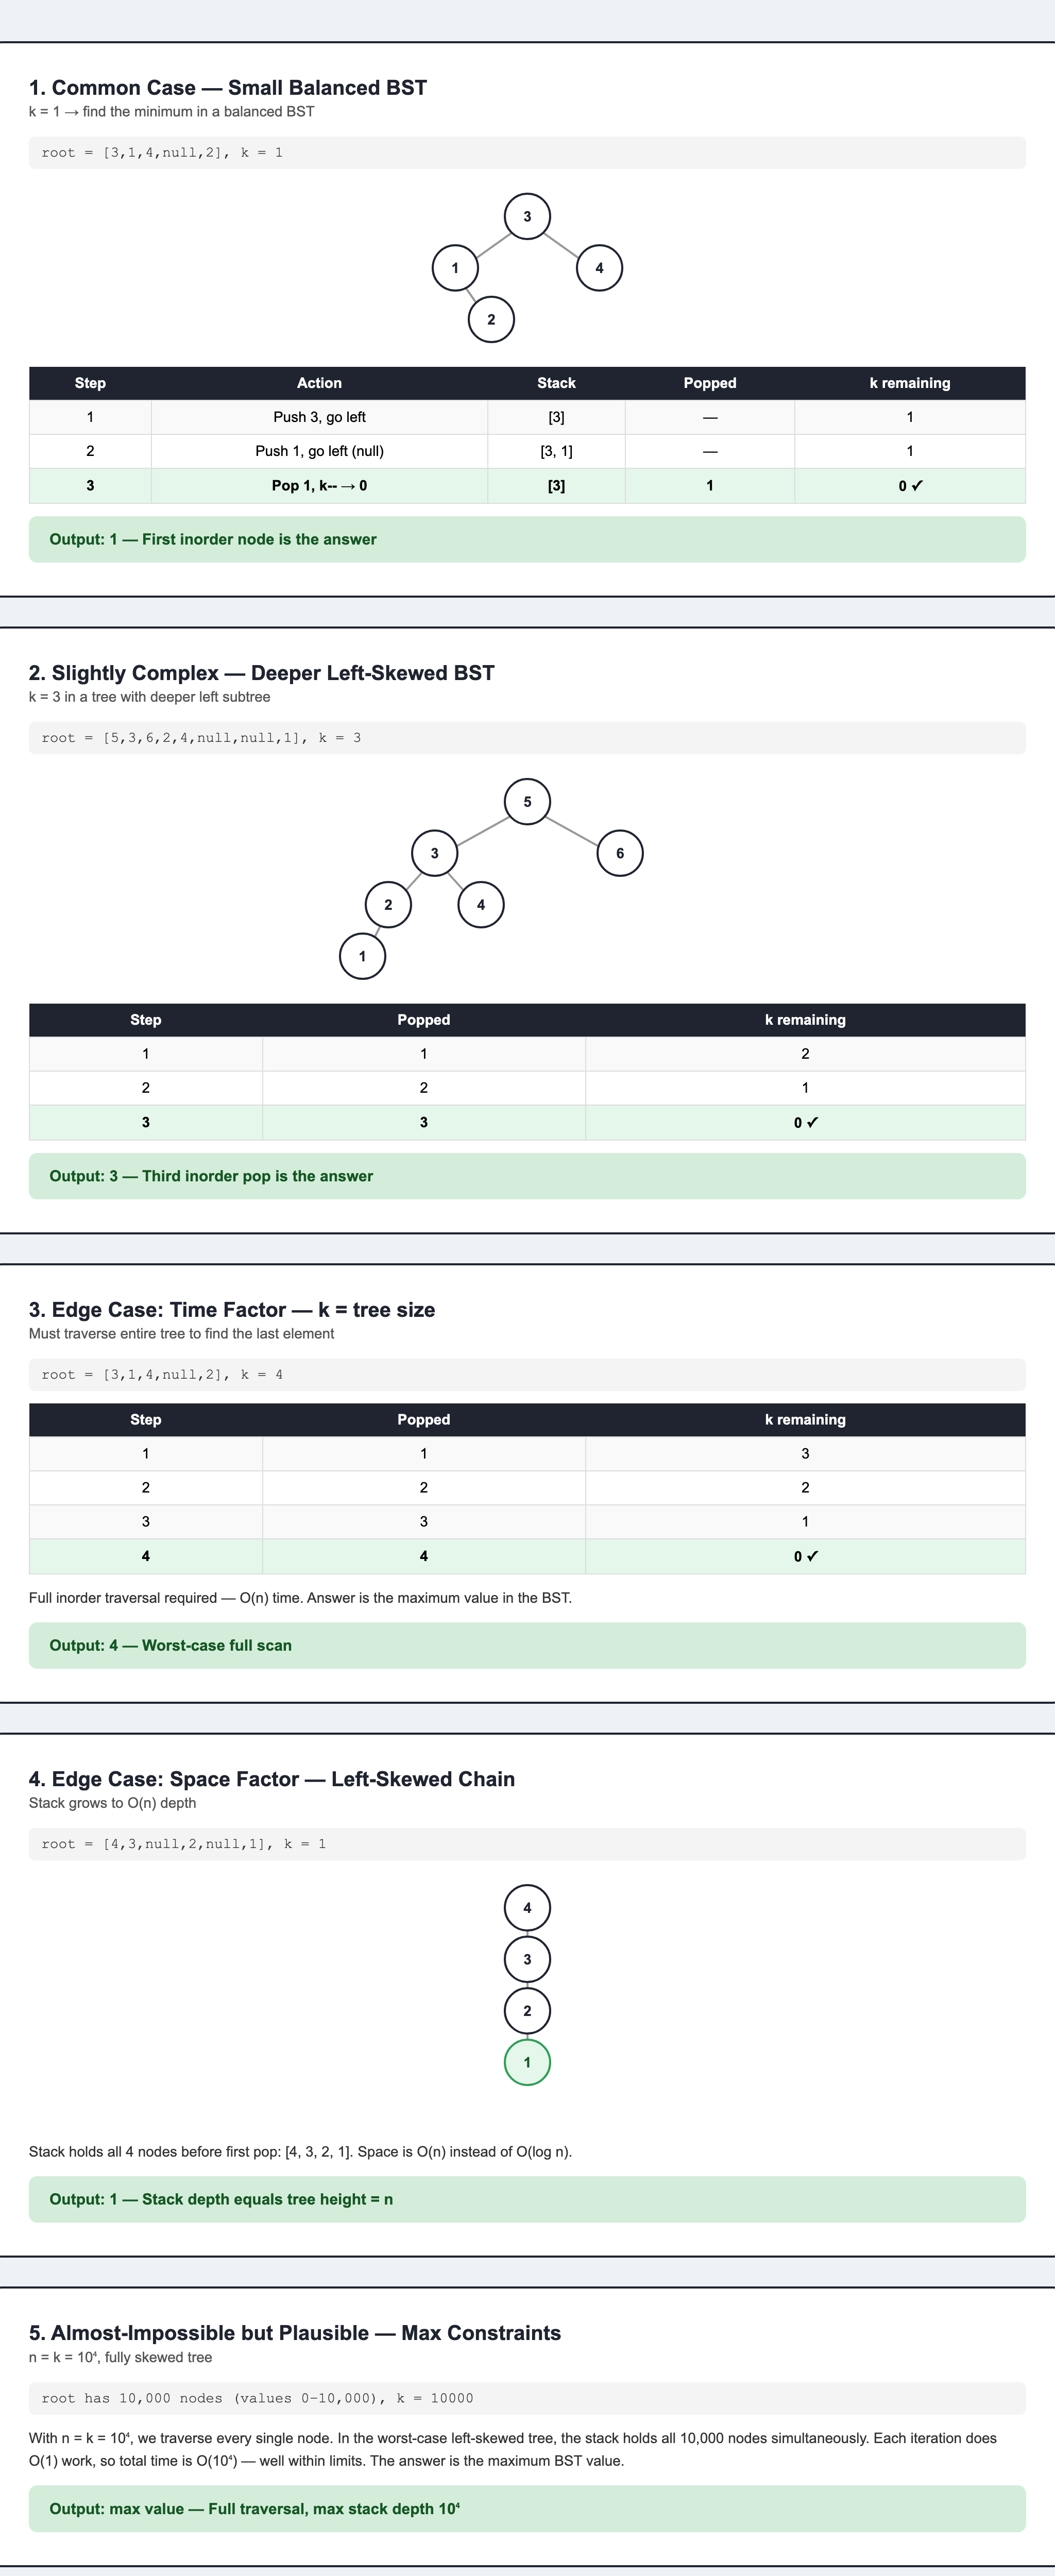